In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
from scipy.signal import welch, detrend
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

from darts import TimeSeries
from darts.models import ExponentialSmoothing


/Users/sk/miniforge3/envs/new/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


In [2]:
df = pd.read_csv(r"/Users/sk/Downloads/filled_data 1.csv")
df.head()

,Station number,Lat,Long,Alt,East/West,Coastal,Year,Month,rain,sun,Lowest max,Highest min,Log(one plus rain)
0,14015,12.42,130.89,30,W,1,1941,1,508.4,20.2,31.1,27.3,6.233234
1,14015,12.42,130.89,30,W,1,1941,2,371.9,20.4,28.8,28.5,5.921310
2,14015,12.42,130.89,30,W,1,1941,3,304.3,20.5,28.2,26.6,5.721295
3,14015,12.42,130.89,30,W,1,1941,4,27.1,20.7,31.0,25.6,3.335770
4,14015,12.42,130.89,30,W,1,1941,5,8.9,20.9,26.6,23.9,2.292535


In [3]:
grouped = df.groupby("Station number")
for station_id, g in grouped:
    print(station_id)
    print(g.head())

9225
       Station number    Lat    Long  Alt East/West  Coastal  Year  Month  \
13011            9225  31.92  115.87   25         W        1  1990      1   
13012            9225  31.92  115.87   25         W        1  1990      2   
13013            9225  31.92  115.87   25         W        1  1990      3   
13014            9225  31.92  115.87   25         W        1  1990      4   
13015            9225  31.92  115.87   25         W        1  1990      5   

       rain   sun  Lowest max  Highest min  Log(one plus rain)  
13011  16.4  27.5        20.2         21.3            2.855985  
13012  16.5  24.6        19.9         21.1            2.861926  
13013  16.6  17.9        19.5         20.8            2.867866  
13014  16.7  14.1        19.2         20.6            2.873807  
13015  16.8  10.8        18.9         20.3            2.879748  
13011
       Station number    Lat    Long  Alt East/West  Coastal  Year  Month  \
13445           13011  26.13  126.58  459         W        

In [8]:
# Example: df with a 'value' column
# df['value'] = [your time series data]

# First differencing (trend)
df['trend_diff_s'] = df['sun'].diff(1)

# Drop the first row which will be NaN
df = df.dropna()

In [9]:



# Seasonal differencing (e.g., previous year's same season)
df['seasonal_diff_s'] = df['sun'].diff(4)

# Drop NaN rows caused by seasonal differencing
df = df.dropna()

# Combined differencing: (1 - B)(1 - B^m)
m = 4  # seasonal period

df['combined_diff_s'] = df['sun'].diff(1).diff(m)

# Drop NaN rows
df = df.dropna()

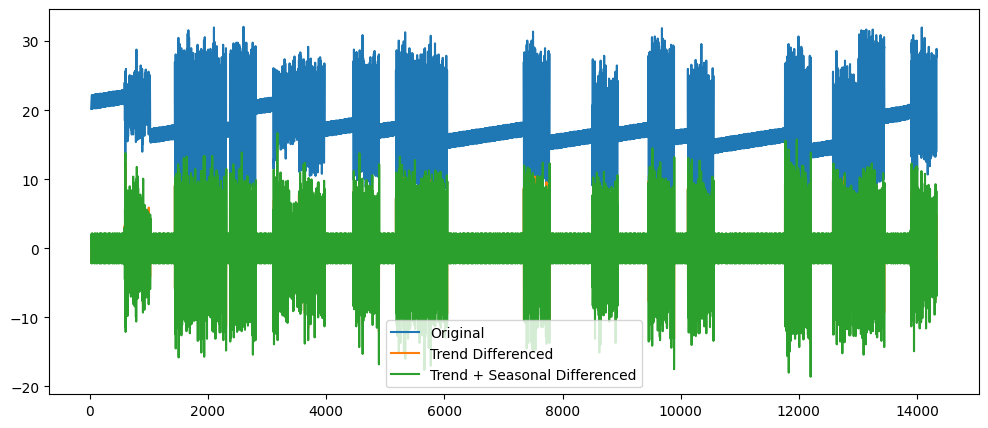

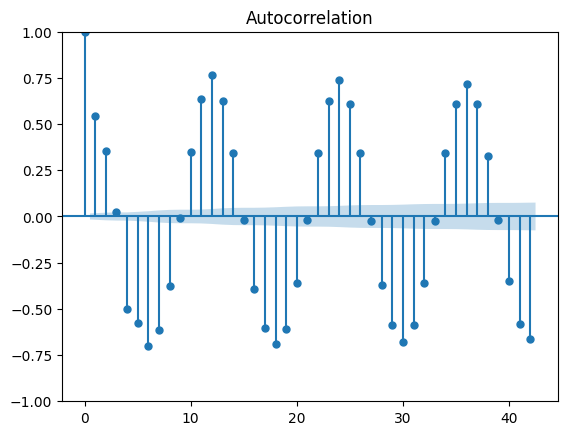

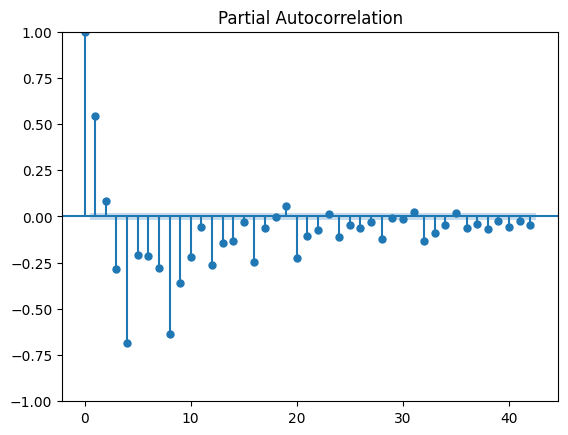

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df['sun'], label='Original')
plt.plot(df['trend_diff_s'], label='Trend Differenced')
plt.plot(df['combined_diff_s'], label='Trend + Seasonal Differenced')
plt.legend()
plt.show()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['combined_diff_s'])
plot_pacf(df['combined_diff_s'])
plt.show()

In [7]:
# Window size for rolling mean (e.g., 4 for quarterly data)
window = 4

# Compute rolling mean
df['rolling_mean_s'] = df['combined_diff_s'].rolling(window=window).mean()

# Shift to forecast the next time step
df['forecast_s'] = df['rolling_mean_s'].shift(1)

# Drop initial NaN rows
df = df.dropna()

print(df.tail())

# Start with the last 'window' observations
last_obs = df['combined_diff_s'].iloc[-window:].tolist()
forecast_horizon = 3
forecasts = []

for _ in range(forecast_horizon):
    next_forecast = sum(last_obs[-window:]) / window
    forecasts.append(next_forecast)
    last_obs.append(next_forecast)

print(f"Next {forecast_horizon} forecasts: {forecasts}")

# Suppose combined_diff = differenced series
# last actual value of original series
last_actual_s = df['sun'].iloc[-1]

# Reverse differencing
forecast_original_scale_s = [last_actual_s + forecasts[0]]
for f in forecasts[1:]:
    forecast_original_scale_s.append(forecast_original_scale_s[-1] + f)

print(forecast_original_scale_s)

forecast_original_scale_s = [np.exp(f) for f in forecast_original_scale_s]

       Station number    Lat    Long  Alt East/West  Coastal  Year  Month  \
14329           13011  26.13  126.58  459         W        0  2025     10   
14330           13011  26.13  126.58  459         W        0  2025     11   
14331           13011  26.13  126.58  459         W        0  2025     12   
14332           13011  26.13  126.58  459         W        0  2026      1   
14333           13011  26.13  126.58  459         W        0  2026      2   

       rain   sun  Lowest max  Highest min  Log(one plus rain)  trend_diff_s  \
14329  14.6  25.0        27.2         28.1            2.747271           2.9   
14330  36.8  26.8        19.3         25.8            3.632309           1.8   
14331   9.0  28.9        33.4         27.7            2.302585           2.1   
14332  10.6  26.9        22.4         21.7            2.451005          -2.0   
14333  16.7  27.8        22.1         21.4            2.871482           0.9   

       seasonal_diff_s  combined_diff_s  rolling_mean_s 

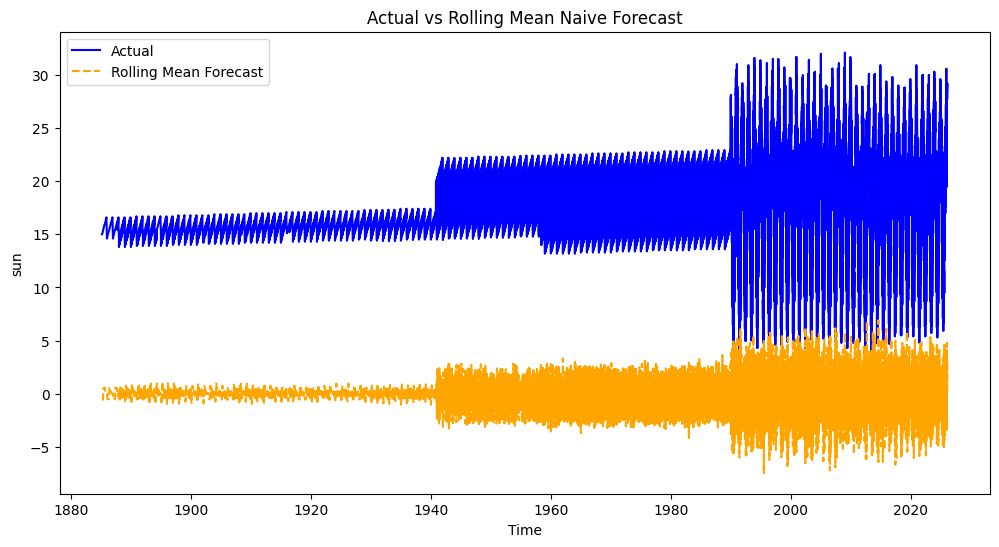

In [54]:
plt.figure(figsize=(12,6))

# Plot actual values
plt.plot(df.index, df['sun'], label='Actual', color='blue')

# Plot forecasted values
plt.plot(df.index, df['forecast'], label='Rolling Mean Forecast', color='orange', linestyle='--')

plt.title('Actual vs Rolling Mean Naive Forecast')
plt.xlabel('Time')
plt.ylabel('sun')
plt.legend()
plt.show()

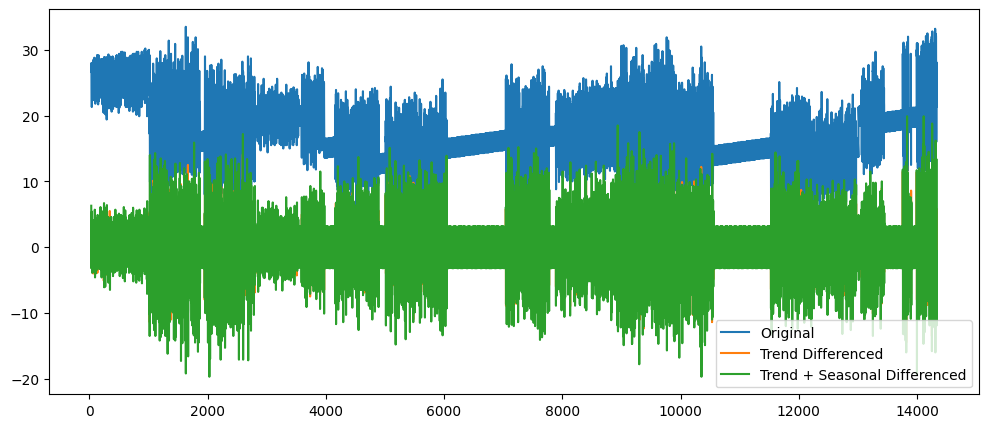

       Station number    Lat    Long  Alt East/West  Coastal  Year  Month  \
14329           13011  26.13  126.58  459         W        0  2025     10   
14330           13011  26.13  126.58  459         W        0  2025     11   
14331           13011  26.13  126.58  459         W        0  2025     12   
14332           13011  26.13  126.58  459         W        0  2026      1   
14333           13011  26.13  126.58  459         W        0  2026      2   

       rain   sun  ...  trend_diff_s  seasonal_diff_s  combined_diff_s  \
14329  14.6  25.0  ...           2.9             11.0              4.1   
14330  36.8  26.8  ...           1.8             12.0              1.0   
14331   9.0  28.9  ...           2.1             11.7             -0.3   
14332  10.6  26.9  ...          -2.0              4.8             -6.9   
14333  16.7  27.8  ...           0.9              2.8             -2.0   

       rolling_mean_s  forecast_s  trend_diff_hm  seasonal_diff_hm  \
14329           5.475 

In [11]:
# First differencing (trend)
df['trend_diff_hm'] = df['Highest min'].diff(1)

# Drop the first row which will be NaN
df_hm = df.dropna()

# Seasonal differencing (e.g., previous year's same season)
df['seasonal_diff_hm'] = df['Highest min'].diff(4)

# Drop NaN rows caused by seasonal differencing
df = df.dropna()

# Combined differencing: (1 - B)(1 - B^m)
m = 4  # seasonal period

df['combined_diff_hm'] = df['Highest min'].diff(1).diff(m)

# Drop NaN rows
df = df.dropna()

plt.figure(figsize=(12,5))
plt.plot(df['Highest min'], label='Original')
plt.plot(df['trend_diff_hm'], label='Trend Differenced')
plt.plot(df['combined_diff_hm'], label='Trend + Seasonal Differenced')
plt.legend()
plt.show()

# Window size for rolling mean (e.g., 4 for quarterly data)
window = 4

# Compute rolling mean
df['rolling_mean_hm'] = df['combined_diff_hm'].rolling(window=window).mean()

# Shift to forecast the next time step
df['forecast_hm'] = df['rolling_mean_hm'].shift(1)

# Drop initial NaN rows
df = df.dropna()

print(df.tail())

# Start with the last 'window' observations
last_obs = df['combined_diff_hm'].iloc[-window:].tolist()
forecast_horizon = 36
forecasts = []

for _ in range(forecast_horizon):
    next_forecast = sum(last_obs[-window:]) / window
    forecasts.append(next_forecast)
    last_obs.append(next_forecast)

print(f"Next {forecast_horizon} forecasts: {forecasts}")

# Suppose combined_diff = differenced series
# last actual value of original series
last_actual_hm = df['Highest min'].iloc[-1]

# Reverse differencing
forecast_original_scale_hm = [last_actual_hm + forecasts[0]]
for f in forecasts[1:]:
    forecast_original_scale_hm.append(forecast_original_scale_hm[-1] + f)

print(forecast_original_scale_hm)

# forecast_original_scale_hm = [np.exp(f) for f in forecast_original_scale_hm]


/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_61765/3180671819.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_index = pd.date_range(start=last_date, periods=forecast_horizon + 1, freq='Q')[1:]


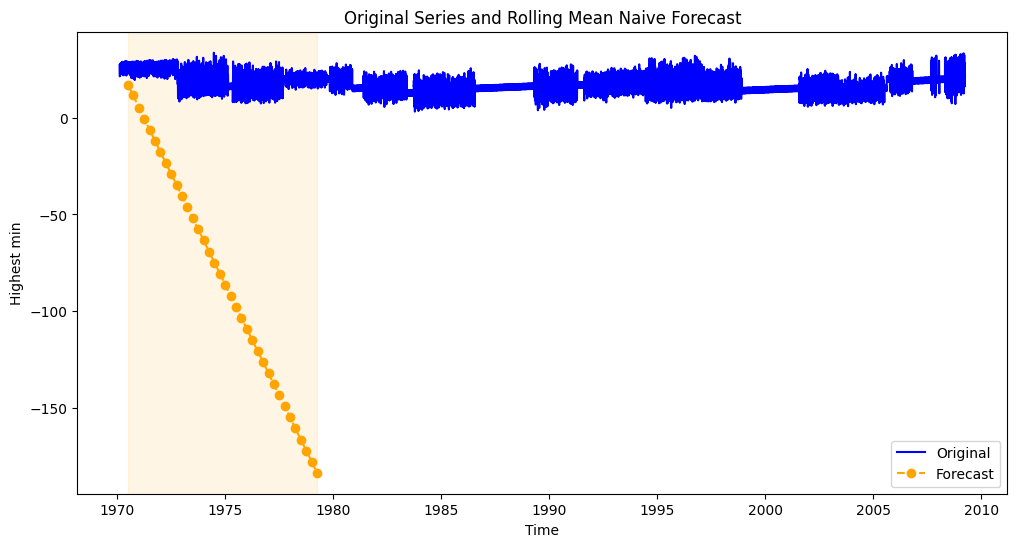

In [12]:
# Last date in the original series
last_date = df.index[-1]

# Forecast horizon
forecast_horizon = len(forecast_original_scale_hm)

# Create future index (assuming quarterly data, adjust 'freq' to your actual frequency)
# Examples: 'Q' = quarterly, 'M' = monthly, 'D' = daily
future_index = pd.date_range(start=last_date, periods=forecast_horizon + 1, freq='Q')[1:]

# Convert the list of forecasted values to a Pandas Series with future index
forecast_series = pd.Series(forecast_original_scale_hm, index=future_index)

plt.figure(figsize=(12,6))

# Original series
plt.plot(df.index, df['Highest min'], label='Original', color='blue')

# Forecasted values
plt.plot(forecast_series.index, forecast_series, label='Forecast', color='orange', linestyle='--', marker='o')

# Optional: shade forecast period
plt.axvspan(forecast_series.index[0], forecast_series.index[-1], color='orange', alpha=0.1)

plt.title('Original Series and Rolling Mean Naive Forecast')
plt.xlabel('Time')
plt.ylabel('Highest min')
plt.legend()
plt.show()

Number of rows after differencing: 14292
First 5 rows:
     Station number    Lat    Long  Alt East/West  Coastal  Year  Month   rain  \
42           14015  12.42  130.89   30         W        1  1944      7    0.0   
43           14015  12.42  130.89   30         W        1  1944      8    0.0   
44           14015  12.42  130.89   30         W        1  1944      9    5.3   
45           14015  12.42  130.89   30         W        1  1944     10   82.3   
46           14015  12.42  130.89   30         W        1  1944     11  229.4   

     sun  ...  seasonal_diff_s  combined_diff_s  rolling_mean_s    forecast_s  \
42  21.3  ...              0.7    -3.552714e-15    5.250000e-01  5.250000e-01   
43  21.5  ...              0.7     0.000000e+00    5.250000e-01  5.250000e-01   
44  21.7  ...              0.7     0.000000e+00   -2.500000e-02  5.250000e-01   
45  21.8  ...              0.7     0.000000e+00   -8.881784e-16 -2.500000e-02   
46  22.0  ...              0.7     0.000000e+00    0

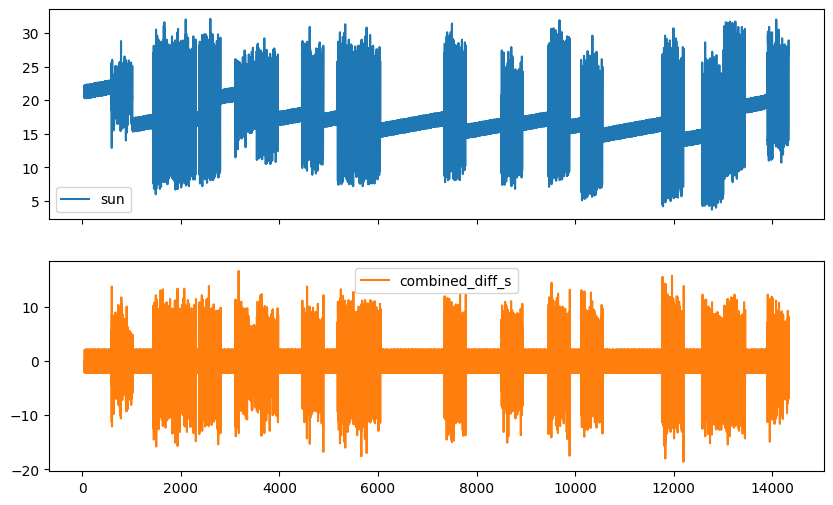

In [13]:
# Example: df with a 'sun' column
# df['sun'] = [your time series data]

m = 4  # seasonal period

# --- 1️⃣ First differencing (remove trend) ---
df['trend_diff_s'] = df['sun'].diff(1)

# --- 2️⃣ Seasonal differencing (remove seasonality) ---
df['seasonal_diff_s'] = df['sun'].diff(m)

# --- 3️⃣ Combined differencing (trend + seasonal) ---
# Correct formula: (1 - B)(1 - B^m)X_t = X_t - X_{t-1} - X_{t-m} + X_{t-m-1}
df['combined_diff_s'] = df['sun'].diff(1).diff(m)

# --- 4️⃣ Optional: manual verification ---
df['manual_combined'] = df['sun'] - df['sun'].shift(1) - df['sun'].shift(m) + df['sun'].shift(m+1)

# Check if combined_diff_s matches manual_combined
if not df['combined_diff_s'].equals(df['manual_combined']):
    print("Warning: combined differencing does not match manual formula!")

# --- 5️⃣ Drop NaN values once at the end ---
df_clean = df.dropna().copy()

# --- 6️⃣ Quick checks ---
print("Number of rows after differencing:", len(df_clean))
print("First 5 rows:\n", df_clean.head())

# Optional: check stationarity visually
import matplotlib.pyplot as plt
df_clean[['sun','combined_diff_s']].plot(subplots=True, figsize=(10,6))
plt.show()